In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import anndata as ad
import os
import sys
import scipy
from scipy.io import mmread
from io import StringIO
import re
import matplotlib.pyplot as plt
import seaborn as sns
import logging

os.chdir("/g/stegle/schrod/code/TCell")
from utils import *
logger = get_logger(__name__)

In [2]:
logger.info(f"Define data paths...")
data_dir = "/g/stegle/schrod/data/T_Cell/"
figure_path = "/g/stegle/schrod/code/TCell/plots/promoter"
guide_dir = "/g/steinmetz/project/otar_2063/promoter_screen/interpretation/guide_assignments/matrix/"
raw_data_path = "/g/steinmetz/project/otar_2063/promoter_screen/processing/combine_data/results/combined_anndata.h5ad"


[2026-01-20 14:01:31,455] INFO:utils: Define data paths...


In [3]:
logger.info(f"Load combined_anndata...")
adata = sc.read_h5ad(raw_data_path)
adata.obs["batch"] = adata.obs.bpcells_name.apply(lambda x: x[:2])
logger.info(f"adata shape: {adata.shape}")

[2026-01-20 14:01:31,499] INFO:utils: Load combined_anndata...
[2026-01-20 14:09:05,056] INFO:utils: adata shape: (2607658, 57259)


In [4]:
logger.info(f"Load Guide mtx...")
with open(f"{guide_dir}/grna_assignment_matrix.mtx") as file:
    guide_assignment_mm = mmread(file, spmatrix=False)
col_names = pd.read_csv(f"{guide_dir}/grna_assignment_matrix_colnames.txt", header = None)
row_names = pd.read_csv(f"{guide_dir}/grna_assignment_matrix_rownames.txt", header = None)
adata = adata[col_names[0]]
logger.info(f"Guide mtx shape: {guide_assignment_mm.shape}")

[2026-01-20 14:09:05,105] INFO:utils: Load Guide mtx...
[2026-01-20 14:09:07,222] INFO:utils: Guide mtx shape: (21893, 2393341)


In [5]:
"""Get Highly variable genes"""
get_highly_variable_genes = False
if get_highly_variable_genes:
    """
    Single-cell RNA-seq data were normalized to library size, log-transformed, and processed to account for batch effects. 
    Highly variable genes (HVGs) were identified using scanpys highly_variable_genes function. 
    Further, to preserve knockdown-relevant features, all promoter-associated target genes from the perturbation experiment were included in addition to HVGs. 
    Genes corresponding to guide sequences and mitochondrial transcripts were excluded. This filtering yielded a final set of 8,024 genes for downstream analyses.
    """

    #%%
    logger.info(f"Normalize data...")
    sc.pp.normalize_total(adata)

    logger.info(f"Log transform data...")
    sc.pp.log1p(adata)

    logger.info(f"Compute highly_variable genes...")
    sc.pp.highly_variable_genes(adata, batch_key="batch")


    #%%
    logger.info(f"Subset genes to highly variable + targets...")
    targets = row_names[0].apply(lambda x: re.sub(r'^.*?-', '',re.sub(r'-[^-]*$', '', x))).unique()
    target_mask = adata.var.bpcells_name.isin(targets)
    print(f"{np.logical_and(target_mask,adata.var.highly_variable).sum()} from {adata.var.highly_variable.sum()} highly variable genes are in targets")
    hvg_mask = np.logical_or(target_mask,adata.var.highly_variable)
    adata = adata[:,hvg_mask]

    hvg_list = adata.var.highly_variable
    hvg_list = hvg_list[hvg_list]

    logger.info(f"Remove guides and MT- genes...")
    MT_genes = [gene for gene in adata.var_names if "MT-" in gene]
    Guides = [gene for gene in adata.var_names if "GUIDE-" in gene]
    additional_MT_genes = ["MT2A", "MTRNR2L12", "MTCH1", "MTRNR2L8", "MT1E"]    # Not starting with MT-

    hvg_list = hvg_list[~hvg_list.index.isin(Guides)]
    hvg_list = hvg_list[~hvg_list.index.isin(MT_genes)]
    hvg_list = hvg_list[~hvg_list.index.isin(additional_MT_genes)]
    hvg_list.to_csv(os.path.join(data_dir, f"combined_anndata_hvg.csv"))

In [6]:
logger.info(f"Subset andata to highly variable and target genes...")
hvg_list=pd.read_csv(os.path.join(data_dir, f"combined_anndata_hvg.csv"),index_col=0)
targets = row_names[0].apply(lambda x: re.sub(r'^.*?-', '',re.sub(r'-[^-]*$', '', x))).unique()
target_mask = adata.var.bpcells_name.isin(targets)
hvg_mask = np.logical_or(target_mask,np.isin(target_mask.index, hvg_list.index))
adata = adata[:,hvg_mask].copy()
logger.info(f"adata shape after subsetting to HVG + targets: {adata.shape}")

[2026-01-20 14:09:07,276] INFO:utils: Subset andata to highly variable and target genes...


[2026-01-20 14:10:55,786] INFO:utils: adata shape after subsetting to HVG + targets: (2393341, 8001)


In [7]:
#%%
logger.info(f"Number of assigned cells...")
mask_single_guide = guide_assignment_mm.sum(0) == 1
print("Cells with exactly one guide: ", mask_single_guide.sum())

mask_two_guides = guide_assignment_mm.sum(0) == 2
print("Cells with two guides: ", mask_two_guides.sum())

mask_no_guides = guide_assignment_mm.sum(0) == 0
print("Cells with no guides: ", mask_no_guides.sum())

mask_more_than_two_guides = guide_assignment_mm.sum(0) > 2
print("Cells with more than two guides: ", mask_more_than_two_guides.sum())

[2026-01-20 14:10:55,892] INFO:utils: Number of assigned cells...
Cells with exactly one guide:  1410422
Cells with two guides:  445130
Cells with no guides:  342445
Cells with more than two guides:  195344


In [8]:
#%%
logger.info(f"Subset adata to single guides...")
adata = adata[mask_single_guide]
guide_assignment_mm = guide_assignment_mm.tocsr().T[mask_single_guide]
col_names = col_names[mask_single_guide]
logger.info(f"adata shape after subsetting to single guides: {adata.shape}")    

[2026-01-20 14:10:55,938] INFO:utils: Subset adata to single guides...
[2026-01-20 14:10:56,110] INFO:utils: adata shape after subsetting to single guides: (1410422, 8001)


In [9]:
logger.info(f"Make list of guides and add to andata for cells with single guide...")
guide_idxs = np.argmax(guide_assignment_mm, axis=1)
guide_str = row_names[0][guide_idxs]
adata.obs["guide"] = guide_str.values
adata.obs["guide_idx"] = guide_idxs
adata.obs

[2026-01-20 14:10:56,116] INFO:utils: Make list of guides and add to andata for cells with single guide...


/scratch/jobs/46746714/ipykernel_8176/3220042625.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["guide"] = guide_str.values


,bpcells_name,batch,guide,guide_idx
bpcells_name,,,,
A3_1_1117,A3_1_1117,A3,GUIDE-NUP107-3,6433
A3_1_9330,A3_1_9330,A3,GUIDE-ZNF514-1,13090
A3_1_9970,A3_1_9970,A3,GUIDE-TNIK-3,21888
A3_1_12073,A3_1_12073,A3,GUIDE-ZNF417-1,12969
A3_1_19218,A3_1_19218,A3,GUIDE-MOGS-3,16652
...,...,...,...,...
C7_8_56617714,C7_8_56617714,C7,GUIDE-COQ5-1,12307
C7_8_56617794,C7_8_56617794,C7,GUIDE-UBA7-2,5362
C7_8_56618153,C7_8_56618153,C7,GUIDE-TMEM101-1,1873


In [10]:
#%%
logger.info(f"Generate target and target_idx columns...")
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
guide_str_simple = adata.obs.guide.apply(lambda x: re.sub(r'^.*?-', '',re.sub(r'-[^-]*$', '', x)))
guide_idxs_simple = le.fit_transform(guide_str_simple)
adata.obs["target_idx"] = guide_idxs_simple
adata.obs["target"] = guide_str_simple.values
adata.obs["donor"] = adata.obs.batch.apply(lambda x: x[0])
adata.obs

[2026-01-20 14:11:18,524] INFO:utils: Generate target and target_idx columns...


,bpcells_name,batch,guide,guide_idx,target_idx,target,donor
bpcells_name,,,,,,,
A3_1_1117,A3_1_1117,A3,GUIDE-NUP107-3,6433,4164,NUP107,A
A3_1_9330,A3_1_9330,A3,GUIDE-ZNF514-1,13090,7417,ZNF514,A
A3_1_9970,A3_1_9970,A3,GUIDE-TNIK-3,21888,6533,TNIK,A
A3_1_12073,A3_1_12073,A3,GUIDE-ZNF417-1,12969,7372,ZNF417,A
A3_1_19218,A3_1_19218,A3,GUIDE-MOGS-3,16652,3630,MOGS,A
...,...,...,...,...,...,...,...
C7_8_56617714,C7_8_56617714,C7,GUIDE-COQ5-1,12307,1310,COQ5,C
C7_8_56617794,C7_8_56617794,C7,GUIDE-UBA7-2,5362,6772,UBA7,C
C7_8_56618153,C7_8_56618153,C7,GUIDE-TMEM101-1,1873,6406,TMEM101,C


In [11]:
save_name = "promoter_single_guide_hvg_raw_counts.h5ad"
logger.info(f"Save '{save_name}' including a total of {adata.shape[0]} cells and {adata.shape[1]} highly variable genes")
adata.write(os.path.join(data_dir, save_name))

[2026-01-20 14:11:20,797] INFO:utils: Save 'promoter_single_guide_hvg_raw_counts.h5ad' including a total of 1410422 cells and 8001 highly variable genes


In [12]:
#%%
save_name_norm_log = "promoter_single_guide_hvg.h5ad"
logger.info(f"Save '{save_name_norm_log}' including a total of {adata.shape[0]} cells and {adata.shape[1]} highly variable genes")
norm_log(adata, logger=logger)
adata.write(os.path.join(data_dir, save_name_norm_log))

[2026-01-20 14:13:34,439] INFO:utils: Save 'promoter_single_guide_hvg.h5ad' including a total of 1410422 cells and 8001 highly variable genes
[2026-01-20 14:13:34,440] INFO:utils: Normalize data...
[2026-01-20 14:13:57,528] INFO:utils: Log transform data...


[2026-01-20 14:16:23,095] INFO:utils: Plot UMAPs for cells with single guide...
[2026-01-20 14:16:23,098] INFO:utils: Compute pca...


[2026-01-20 14:33:37,083] INFO:utils: Compute nearest neighbours...


/g/stegle/schrod/code/TCell/otar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-01-20 14:37:57,510] INFO:utils: Compute umap encoding...


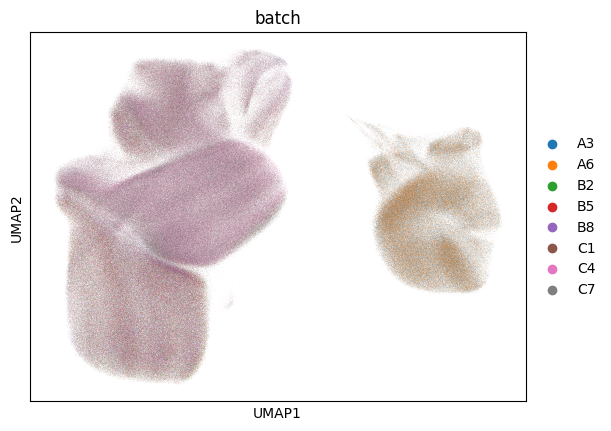

In [13]:
logger.info(f"Plot UMAPs for cells with single guide...")
preprocess(adata, logger=logger)
plot_umap(adata, "batch", os.path.join(figure_path, "UMAP/cells_with_one_guide_per_donor.png"))
